# Properties of the Derivative — Multiplication by Scalars

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on the **scalar-multiple rule**
(Week 1 — Derivatives and Optimization).

This is the first of the **derivative rules** that let us differentiate complicated
functions by building on simple ones (scalar multiplication, sum, product, chain).

This notebook explains:

- the rule: if $f = c\cdot g$, then $f' = c\cdot g'$
- *why* — vertically stretching a graph by $c$ multiplies every slope by $c$
- worked examples (e.g. $x^2$ slope $2$ at $x=1$ becomes $4$ for $2x^2$), with SymPy

This notebook follows the repository `GUIDELINES.md` template and continues the Week 1
derivatives material.

## 1. The derivative rules

To differentiate more complicated functions, we **piggyback** on the simple derivatives
using a few rules:

- **multiplication by scalars** (this notebook),
- the **sum rule**,
- the **product rule**,
- the **chain rule**.

This notebook covers the scalar-multiple rule.

## 2. The rule

If a function is a **constant times** another function, its derivative is that same constant
times the other derivative:

$$
f(x) = c\,g(x) \quad\Longrightarrow\quad f'(x) = c\,g'(x).
$$

This holds for **any** constant $c$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x, c = sp.symbols('x c')
g = sp.Function('g')

# symbolically: d/dx [c * g(x)] = c * g'(x)
print("d/dx [c*g(x)] =", sp.diff(c*g(x), x))

d/dx [c*g(x)] = c*Derivative(g(x), x)


## 3. Why it works

Compare $y = x^2$ with $y = 2x^2$ — the second is the first **stretched vertically by 2**.

On the left, the secant from $(1,1)$ to $(2,4)$ has slope $\dfrac{4-1}{2-1} = 3$.

On the right, the corresponding points are $(1,2)$ and $(2,8)$: the **run is the same**
($1$) but the **rise doubles** ($8-2 = 6$ instead of $3$), so the slope is
$\dfrac{6}{1} = 6$ — **doubled**.

Every secant slope doubles, so in the limit the **tangent** slope doubles too. The
derivative of $x^2$ at $x=1$ is $2$; for $2x^2$ it becomes $4$.

In [2]:
# secant slopes: left g = x^2, right f = 2 x^2
def g_(x): return x**2
def f_(x): return 2*x**2

run = 2 - 1
print(f"left  (x²):  slope = ({g_(2)} - {g_(1)})/{run} = {(g_(2)-g_(1))/run}")
print(f"right (2x²): slope = ({f_(2)} - {f_(1)})/{run} = {(f_(2)-f_(1))/run}")
print("-> the slope multiplied by 2 (rise doubled, run unchanged)")

# tangent slopes (derivatives) at x=1
x = sp.symbols('x')
print("\nd/dx x²  at 1 =", sp.diff(x**2, x).subs(x, 1))
print("d/dx 2x² at 1 =", sp.diff(2*x**2, x).subs(x, 1))

left  (x²):  slope = (4 - 1)/1 = 3.0
right (2x²): slope = (8 - 2)/1 = 6.0
-> the slope multiplied by 2 (rise doubled, run unchanged)

d/dx x²  at 1 = 2
d/dx 2x² at 1 = 4


## 4. Any scalar $c$

For a general constant $c$, the graph of $c\,g$ is $g$ **stretched vertically by $c$** — as
if you grabbed the top and bottom and pulled. A point $(x, y)$ with tangent slope $g'(x)$
becomes $(x, c\,y)$ with slope $c\,g'(x)$:

$$
\frac{d}{dx}\big[c\,g(x)\big] = c\,g'(x).
$$

In [3]:
x = sp.symbols('x')
g = x**2
for c_val in [2, 5, -3, sp.Rational(1, 2)]:
    print(f"d/dx [{c_val}·x²] = {sp.diff(c_val*g, x)}  =  {c_val}·(2x)")

d/dx [2·x²] = 4*x  =  2·(2x)
d/dx [5·x²] = 10*x  =  5·(2x)
d/dx [-3·x²] = -6*x  =  -3·(2x)
d/dx [1/2·x²] = x  =  1/2·(2x)


### Visualizing the stretch

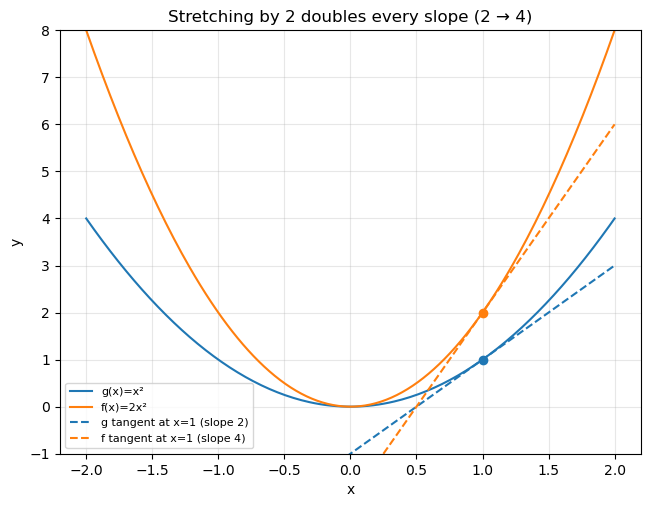

In [4]:
xs = np.linspace(-2, 2, 200)
plt.figure(figsize=(7.5, 5.5))
plt.plot(xs, xs**2, label="g(x)=x²")
plt.plot(xs, 2*xs**2, label="f(x)=2x²")
# tangents at x=1
plt.plot(xs, 1 + 2*(xs-1), "--", color="tab:blue", label="g tangent at x=1 (slope 2)")
plt.plot(xs, 2 + 4*(xs-1), "--", color="tab:orange", label="f tangent at x=1 (slope 4)")
plt.plot(1, 1, "o", color="tab:blue"); plt.plot(1, 2, "o", color="tab:orange")
plt.title("Stretching by 2 doubles every slope (2 → 4)")
plt.xlabel("x"); plt.ylabel("y")
plt.ylim(-1, 8); plt.grid(True, alpha=0.3); plt.legend(fontsize=8)
plt.show()

## 5. Exercises

### Basic
1. State the scalar-multiple rule.
2. If $g'(x) = \cos x$, what is $\dfrac{d}{dx}[5\,g(x)]$?

### Intermediate
3. Differentiate $f(x) = 7x^3$ and $h(x) = -2\sin x$.
4. The derivative of $g$ at $x=1$ is $3$. What is the derivative of $10g$ there?

### Advanced
5. Show, from the limit definition, that $\dfrac{d}{dx}[c\,g(x)] = c\,g'(x)$.
6. Explain geometrically why multiplying a function by $c$ multiplies all its tangent slopes
   by $c$.

## 6. Solutions / Checks

In [5]:
x = sp.symbols('x')

# 3.
print("3. d/dx 7x³ =", sp.diff(7*x**3, x), ";  d/dx (-2 sin x) =", sp.diff(-2*sp.sin(x), x))

# 4.
print("4. derivative of 10g at 1 = 10 * 3 =", 10*3)

# 5.
c, h = sp.symbols('c h')
g = sp.Function('g')
limit_expr = sp.limit((c*g(x + h) - c*g(x))/h, h, 0)
print("5. limit definition d/dx[c g(x)] =", limit_expr)

print("\n1. d/dx[c·g(x)] = c·g'(x).")
print("2. 5·(-... ) -> 5 g'(x) = 5 cos x.")
print("6. Scaling by c stretches the graph vertically by c, so every rise (and slope) scales by c.")

3. d/dx 7x³ = 21*x**2 ;  d/dx (-2 sin x) = -2*cos(x)
4. derivative of 10g at 1 = 10 * 3 = 30
5. limit definition d/dx[c g(x)] = c*Subs(Derivative(g(_xi_1), _xi_1), _xi_1, x)

1. d/dx[c·g(x)] = c·g'(x).
2. 5·(-... ) -> 5 g'(x) = 5 cos x.
6. Scaling by c stretches the graph vertically by c, so every rise (and slope) scales by c.


## 7. Conclusion

- The **scalar-multiple rule**: $\dfrac{d}{dx}\big[c\,g(x)\big] = c\,g'(x)$ for any constant
  $c$.
- Geometrically, multiplying a function by $c$ **stretches it vertically by $c$**, which
  multiplies every secant — and hence every tangent — slope by $c$.
- Example: $\dfrac{d}{dx}x^2 = 2x$, so $\dfrac{d}{dx}2x^2 = 4x$.
- This is the first of the derivative rules; next come the **sum**, **product**, and
  **chain** rules.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/index (17).mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 1) lecture **properties of the derivative — multiplication by scalars**. Key
spoken points, lightly cleaned:

> To differentiate more complicated functions, use rules that build on the simple
> derivatives: multiplication by scalars, the sum rule, the product rule, and the chain
> rule. Multiplication by scalars: if $f = 4g$ then $f' = 4g'$, and for any constant $c$, $f
> = c\,g$ gives $f' = c\,g'$. Why? Compare $y = x^2$ with $2x^2$ (the function doubled). On
> the left the secant from $(1,1)$ to $(2,4)$ has slope $3$; on the right the points are
> $(1,2)$ and $(2,8)$, with the same run but double the rise, so slope $6$ — doubled. Every
> slope doubles, so in the limit the tangent slope doubles: the derivative of $x^2$ at $1$ is
> $2$, and for $2x^2$ it's $4$. In general, multiplying by $c$ stretches the graph vertically
> by $c$, so a point $(x,y)$ with slope $f'(x)$ becomes $(x, c\,y)$ with slope $c\,f'(x)$.